# **Interactive Building Extraction with SAM3**

This notebook demonstrates how to segment remote sensing images interactively using the Segment Anything Model 3 (SAM3). For detiled model impementation and further resources please consult Meta's page [HERE](https://ai.meta.com/research/sam3/) and the SAM3 paper [HERE](https://ai.meta.com/research/sam3/)

# **Installation**

This notebook accesses a SAM 3 impementation wraped to segmentgeopatial implemetation. For further details, integration with QGIS and ArcGIS pro environemnt, please consult from the [SOURCE](https://github.com/opengeos/segment-geospatial)

In [1]:
%pip install "segment-geospatial[samgeo3]"
%pip install transformers==5.0.0rc0
%pip install -U huggingface_hub
%pip install kagglehub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 666.8/666.8 kB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.9/149.9 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 121.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.3/21.3 MB 104.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 99.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 121.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 57.3 MB/s eta 0:00:00
   ━━━━

## **Import necessary libraries**


In [2]:
import leafmap  # for interactive visualization
from samgeo import SamGeo3  # A wrapper library for accessing SAM3 for inetractive segmentation
from sys import path
from glob import glob
import os
import rasterio      # for remotely image handeling
from pathlib import Path
from rasterio.merge import merge
import kagglehub                 # To access the data stored in the Kaggle platform
import matplotlib.pyplot as plt

## **Check if cuda GPU available**

In [3]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

/bin/bash: line 1: nvidia-smi: command not found


## **Connect to Google Drive for user data access**

This will help to access and load custome files and processed outputs including trained model weights

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **Access Very High Resolution Data**

For this exercise, the dataset is saved in [Kaggle](https://www.kaggle.com/) plateform. The dataset is observed at Kakuma IDP camp and Kutupalong Refugee camps and was accessed from [Open Aerial Maps](https://openaerialmap.org/).


In [5]:
dataset_path = kagglehub.dataset_download("getachewworkineh/kakuma-ceos-training")
print("Path to dataset files:", dataset_path)
print(f"The folder contains the following files")
os.listdir(dataset_path)

100%|██████████| 0.99G/0.99G [00:05<00:00, 211MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/getachewworkineh/kakuma-ceos-training/versions/4
The folder contains the following files


['kutupalong_a.tif',
 'validation.geojson',
 'kutupalong_f.tif',
 'training.geojson',
 'valid.tif',
 'train.tif',
 'test.tif']

## **Visualize the image for visual inspection**

In [ ]:
image = os.path.join(dataset_path, "kutupalong_f.tif")
os.path.exists(image)

True

In [ ]:
m = leafmap.Map()
m.add_raster(image, layer_name="Satellite image")
m

Map(center=[21.157595, 92.13947350000001], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in…

## **Request access to SAM3**

To use SAM3, we need to request access from Hugging Face: https://huggingface.co/facebook/sam3

Once we have access, we have to get the access token and past on the requested hugging face login and past the token.

In [ ]:
from huggingface_hub import login
login()

## **Initialize SAM3**

When initializing SAM3, you can choose the backend from "meta", or "transformers".

In [ ]:
sam3 = SamGeo3(
    backend="transformers",
    device=None,
    checkpoint_path=None,
    load_from_HF=True
)

Using cpu device and transformers backend


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

## **Set the image**

You can set the image by either passing the image path or the image URL. At the same time we can optimize mask threshold and confidence threshold which are the most important hyperparameters in tunning proper object masks

In [ ]:
# sam3.set_confidence_threshold(0.5)
# sam3.mask_threshold = 0.25
# print(sam3.mask_threshold)
sam3.set_image(image)

## **Generate masks with text prompt**

In [ ]:
sam3.generate_masks(prompt="building")

Found 69 objects.


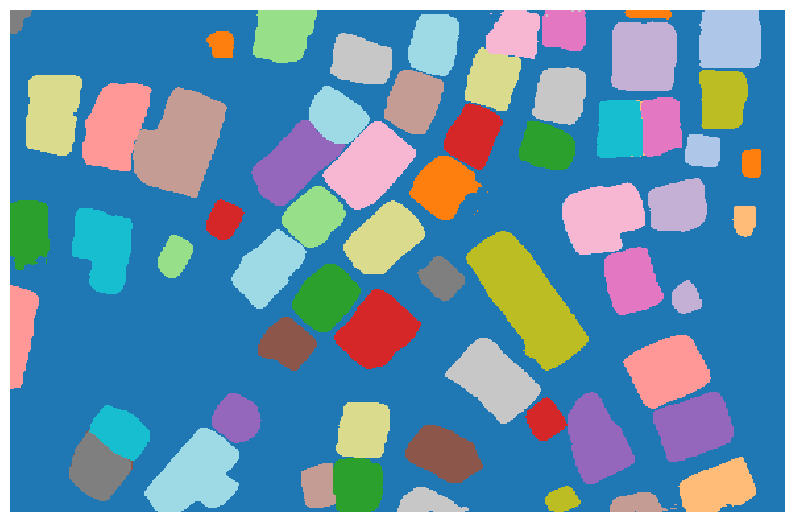

In [ ]:
sam3.show_masks(figsize=(10, 10), unique=True)

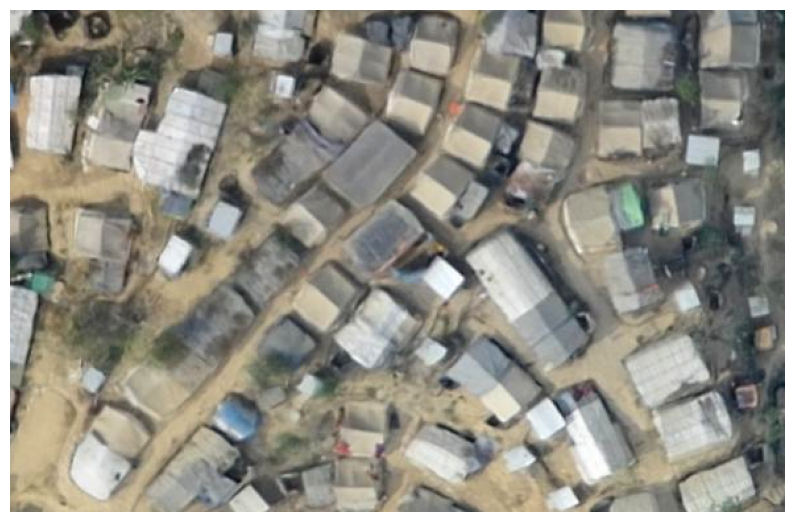

In [ ]:
plt.figure(figsize = (10,10))
plt.imshow(sam3.image)
plt.axis("off")
plt.show()

***Note:***
As we can clearly see the performance is not good. This is mainly affected by the tile size and the diversity of buildings itself in the scene. The solution, work in a more reduced tile size, that can profoundly reduce the bulding spectral diversity per scene.

## **Interactive segmentation**

Interactively segment using text promt or geometric promts (box promts). The underlying architecture is the same except chnaging the promt type.

In [ ]:
sam3.show_map(height="1000px", min_size=10)

Map(center=[21.157595, 92.13947350000001], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in…

## **Tile the image**

Tile the biger image into smaller chips, that can reduce building diversity, and increase the resolution. For this, we will use a custom function.

In [ ]:
import sys
sys.path.append("/content/drive/MyDrive/dataset/code")
from tiling_and_visualization import tile_raster, tile_visualize
from prediction_to_geodata import binary_raster_to_vector

In [ ]:
tile_visualize(raster_file=image,
               tile_height=128,
               tile_width=128,
               stride_y=120,
               stride_x=120)

100%|██████████| 4/4 [00:00<00:00, 775.04it/s]


Map(center=[21.157595, 92.13947350000001], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in…

In [ ]:
tile_raster(input_raster=image,
            output_dir="/content/drive/MyDrive/dataset/TEST_TILES",
            tile_size=128,
            stride=120,
            input_mask_file=None,
            background_value=0)

Raster dimensions: 381 x 588
Number of tiles including background: 3 x 4

Successfully created 20 chips


['chip_0_0.tif',
 'chip_0_120.tif',
 'chip_0_240.tif',
 'chip_0_360.tif',
 'chip_0_480.tif',
 'chip_120_0.tif',
 'chip_120_120.tif',
 'chip_120_240.tif',
 'chip_120_360.tif',
 'chip_120_480.tif',
 'chip_240_0.tif',
 'chip_240_120.tif',
 'chip_240_240.tif',
 'chip_240_360.tif',
 'chip_240_480.tif',
 'chip_360_0.tif',
 'chip_360_120.tif',
 'chip_360_240.tif',
 'chip_360_360.tif',
 'chip_360_480.tif']

## **Automate on small samples**

In [ ]:
# sam3.set_confidence_threshold(0.5)
# sam3.mask_threshold = 0.5

root = "/content/drive/MyDrive/dataset/TEST_TILES/images"
save_dir  = "/content/drive/MyDrive/dataset/TEST_TILES/labels"
files = sorted(glob(root + "/*.tif"))
if not os.path.exists(save_dir):
  os.makedirs(save_dir)
for file in files:
  sam3.set_image(file)
  sam3.generate_masks(prompt="building")
  try:
    sam3.save_masks(f"{save_dir}/masks_{os.path.basename(file)}")
  except:
    pass

Found 16 objects.
Saved 16 mask(s) to /content/drive/MyDrive/dataset/TEST_TILES/labels/masks_chip_0_0.tif
Found 23 objects.
Saved 23 mask(s) to /content/drive/MyDrive/dataset/TEST_TILES/labels/masks_chip_0_120.tif
No objects found. Please try a different prompt.
No objects found. Please try a different prompt.
Found 15 objects.
Saved 15 mask(s) to /content/drive/MyDrive/dataset/TEST_TILES/labels/masks_chip_0_480.tif
Found 16 objects.
Saved 16 mask(s) to /content/drive/MyDrive/dataset/TEST_TILES/labels/masks_chip_120_0.tif
Found 22 objects.
Saved 22 mask(s) to /content/drive/MyDrive/dataset/TEST_TILES/labels/masks_chip_120_120.tif
No objects found. Please try a different prompt.
No objects found. Please try a different prompt.
Found 17 objects.
Saved 17 mask(s) to /content/drive/MyDrive/dataset/TEST_TILES/labels/masks_chip_120_480.tif
Found 12 objects.
Saved 12 mask(s) to /content/drive/MyDrive/dataset/TEST_TILES/labels/masks_chip_240_0.tif
Found 29 objects.
Saved 29 mask(s) to /content

In [ ]:
print(list(glob(f"{save_dir}/*.tif")))

['/content/drive/MyDrive/dataset/TEST_TILES/labels/masks_chip_0_0.tif', '/content/drive/MyDrive/dataset/TEST_TILES/labels/masks_chip_0_120.tif', '/content/drive/MyDrive/dataset/TEST_TILES/labels/masks_chip_0_480.tif', '/content/drive/MyDrive/dataset/TEST_TILES/labels/masks_chip_120_0.tif', '/content/drive/MyDrive/dataset/TEST_TILES/labels/masks_chip_120_120.tif', '/content/drive/MyDrive/dataset/TEST_TILES/labels/masks_chip_120_480.tif', '/content/drive/MyDrive/dataset/TEST_TILES/labels/masks_chip_240_0.tif', '/content/drive/MyDrive/dataset/TEST_TILES/labels/masks_chip_240_120.tif', '/content/drive/MyDrive/dataset/TEST_TILES/labels/masks_chip_240_240.tif', '/content/drive/MyDrive/dataset/TEST_TILES/labels/masks_chip_240_360.tif', '/content/drive/MyDrive/dataset/TEST_TILES/labels/masks_chip_240_480.tif']


In [ ]:
raster_files = list(glob(f"{save_dir}/*.tif"))
paths = [rasterio.open(fls) for fls in raster_files]
dest, output_transform = merge(paths, indexes=1, method="first")
dest = dest>=1
dest = dest.astype(int)

with rasterio.open(raster_files[0]) as src:
    out_meta = src.meta.copy()
    out_meta.update(
        {
            "driver": "GTiff",
            "height": dest.shape[1],
            "width": dest.shape[2],
            "transform": output_transform,
            "count": 1
        }
    )
save_file = f"{save_dir}/merged_final.tif"
with rasterio.open(save_file, "w", **out_meta) as fp:
    fp.write(dest)

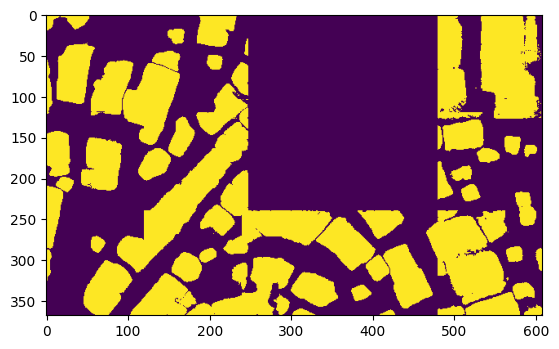

In [ ]:
plt.imshow(dest[0])
plt.show()

In [ ]:
save_file = f"{save_dir}/merged_final.tif"
m = leafmap.Map()
m.add_raster(save_file, layer_name="segmented")
m

Map(center=[21.1576005, 92.1394835], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title…

Saved 55 polygons to /content/drive/MyDrive/dataset/TEST_TILES/labels/merged_final.shp
Found 55 polygons


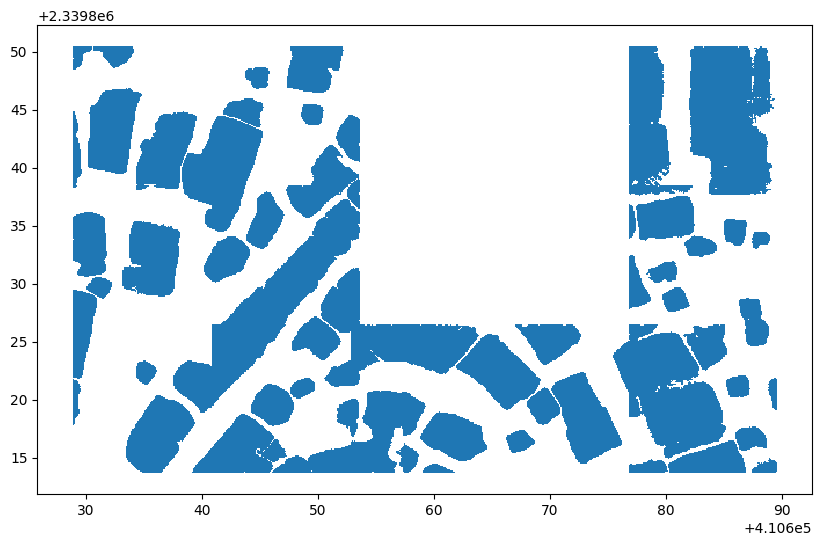

In [ ]:
gdf = binary_raster_to_vector(
        save_file,
        output_path=f"{save_dir}/merged_final.shp",
        mask_value=1,
        simplify_tolerance=None,
        min_area=1.0
    )

print(f"Found {len(gdf)} polygons")

    # Plot the result
if len(gdf) > 0:
    gdf.plot(figsize=(10, 10))
    import matplotlib.pyplot as plt
    plt.show()

In [ ]:
save_file = f"{save_dir}/merged_final.shp"
m = leafmap.Map()
m.add_vector(save_file, layer_name="vector_file")
m

Map(center=[20, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text…

In [ ]:
save_dir = "/content/drive/MyDrive/dataset/TEST_TILES/labels"
saved_image = "/content/drive/MyDrive/dataset/TEST_TILES/labels/merged_final.tif"
gdf_filtered_area = binary_raster_to_vector(
saved_image,
output_path=f"{save_dir}/merged_final_gen.shp",
remove_holes=True,
min_hole_area=2,  # Remove holes smaller than 50 square units
simplify_tolerance=0.9,
min_area=1
)

Saved 52 polygons to /content/drive/MyDrive/dataset/TEST_TILES/labels/merged_final_gen.shp


In [ ]:
save_file = f"{save_dir}/merged_final.shp"
save_file1 = f"{save_dir}/merged_final_gen.shp"
m = leafmap.Map()
m.add_vector(save_file, layer_name="vector_file")
m.add_vector(save_file1, layer_name="1vector_file")
m

Map(center=[20, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text…